In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the engineered dataset
df_model = pd.read_csv("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/engineered_features.csv")
df_model.head()

,Tenure,Monthly Charges,Multiple Lines,Tenure Group,Charge Level,Churn
0,1,29.85,0,0,0,0
1,34,56.95,0,1,1,0
2,2,53.85,0,0,1,1
3,45,42.30,0,2,1,0
4,2,70.70,0,0,2,1


Churn
0    5163
1    1869
Name: count, dtype: int64


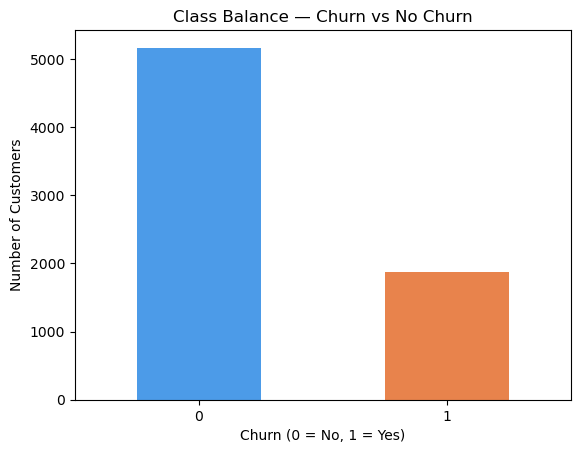

In [3]:
# 1. CLASS BALANCE — how many customers churned vs stayed?
print(df_model["Churn"].value_counts())

df_model["Churn"].value_counts().plot(kind="bar", color=["#4C9BE8", "#E8834C"])
plt.title("Class Balance — Churn vs No Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

Tenure Group
0    47.678161
1    25.538793
2    11.929357
Name: Churn, dtype: float64


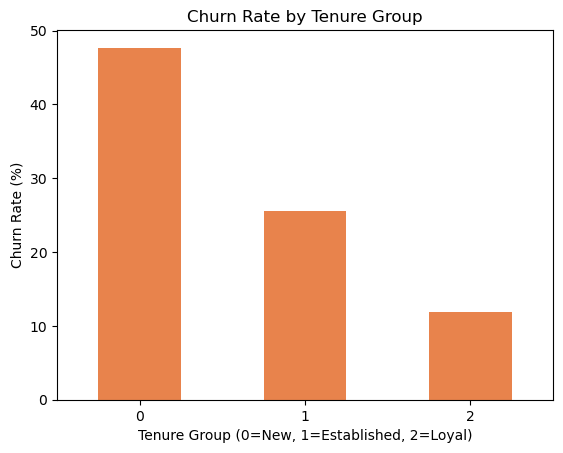

In [4]:
# 2. CHURN RATE BY TENURE GROUP
# 0 = New, 1 = Established, 2 = Loyal
churn_by_tenure = df_model.groupby("Tenure Group")["Churn"].mean() * 100
print(churn_by_tenure)

churn_by_tenure.plot(kind="bar", color="#E8834C")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (0=New, 1=Established, 2=Loyal)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Charge Level
0    10.898551
1    23.690338
2    35.497353
Name: Churn, dtype: float64


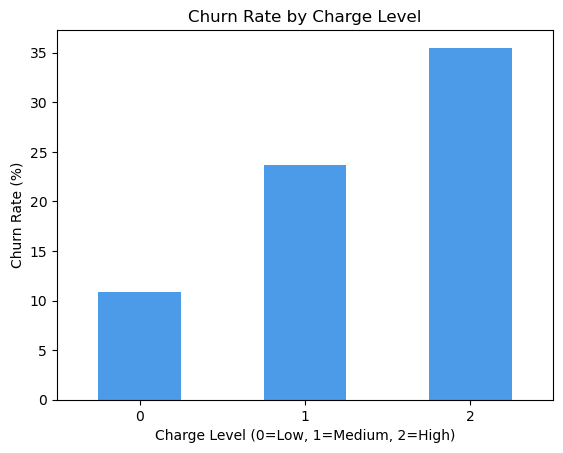

In [5]:
# 3. CHURN RATE BY CHARGE LEVEL
# 0 = Low, 1 = Medium, 2 = High
churn_by_charge = df_model.groupby("Charge Level")["Churn"].mean() * 100
print(churn_by_charge)

churn_by_charge.plot(kind="bar", color="#4C9BE8")
plt.title("Churn Rate by Charge Level")
plt.xlabel("Charge Level (0=Low, 1=Medium, 2=High)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Multiple Lines
0    25.067651
1    28.648466
Name: Churn, dtype: float64


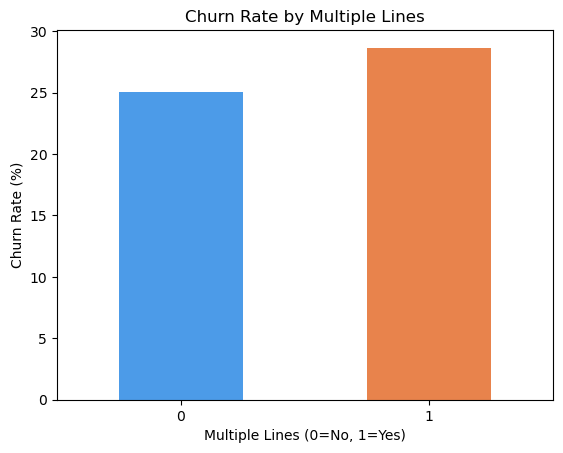

In [6]:
# 4. CHURN RATE BY MULTIPLE LINES
# 0 = No / No Phone Service, 1 = Yes
churn_by_lines = df_model.groupby("Multiple Lines")["Churn"].mean() * 100
print(churn_by_lines)

churn_by_lines.plot(kind="bar", color=["#4C9BE8", "#E8834C"])
plt.title("Churn Rate by Multiple Lines")
plt.xlabel("Multiple Lines (0=No, 1=Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [7]:
# 5. SUMMARY TABLE — churn rate per group
summary = df_model.groupby("Tenure Group")["Churn"].agg(["count", "sum", "mean"])
summary.columns = ["Total Customers", "Churned", "Churn Rate"]
summary["Churn Rate"] = (summary["Churn Rate"] * 100).round(1)
summary.index = ["New", "Established", "Loyal"]
print("Churn by Tenure Group:")
print(summary)
print()

summary2 = df_model.groupby("Charge Level")["Churn"].agg(["count", "sum", "mean"])
summary2.columns = ["Total Customers", "Churned", "Churn Rate"]
summary2["Churn Rate"] = (summary2["Churn Rate"] * 100).round(1)
summary2.index = ["Low", "Medium", "High"]
print("Churn by Charge Level:")
print(summary2)
print()

summary3 = df_model.groupby("Multiple Lines")["Churn"].agg(["count", "sum", "mean"])
summary3.columns = ["Total Customers", "Churned", "Churn Rate"]
summary3["Churn Rate"] = (summary3["Churn Rate"] * 100).round(1)
summary3.index = ["No", "Yes"]
print("Churn by Multiple Lines:")
print(summary3)

Churn by Tenure Group:
             Total Customers  Churned  Churn Rate
New                     2175     1037        47.7
Established             1856      474        25.5
Loyal                   3001      358        11.9

Churn by Charge Level:
        Total Customers  Churned  Churn Rate
Low                1725      188        10.9
Medium             1718      407        23.7
High               3589     1274        35.5

Churn by Multiple Lines:
     Total Customers  Churned  Churn Rate
No              4065     1019        25.1
Yes             2967      850        28.6
